**Análisis de Mortalidad por COVID-19 en México (Enero — Julio 2020)**

Descripción: Identificar los grupos poblacionales con mayor riesgo de mortalidad por COVID-19 es fundamental para las instituciones de salud. Con base en 370,712 casos confirmados del registro oficial de la Secretaría de Salud, este análisis explora el impacto de factores como edad, diabetes y tipo de atención sobre la tasa de mortalidad, con el objetivo de apoyar decisiones clínicas como la priorización en TRIAGE y la gestión eficiente de recursos hospitalarios.

Herramientas:Python, pandas, NumPy, DuckDB, matplotlib, seaborn

Elaborado por: Carlos Roberto Díaz 
LinkedIn: www.linkedin.com/in/carlosrobertod

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalish99/covid19-mx/ORIGEN.csv
/kaggle/input/datasets/lalish99/covid19-mx/covid_mx.csv
/kaggle/input/datasets/lalish99/covid19-mx/ENTIDADES.csv
/kaggle/input/datasets/lalish99/covid19-mx/TIPO_PACIENTE.csv
/kaggle/input/datasets/lalish99/covid19-mx/SI_NO.csv
/kaggle/input/datasets/lalish99/covid19-mx/covid-19_general_MX.csv
/kaggle/input/datasets/lalish99/covid19-mx/RESULTADO.csv
/kaggle/input/datasets/lalish99/covid19-mx/casos_confirmados.csv
/kaggle/input/datasets/lalish99/covid19-mx/NACIONALIDAD.csv
/kaggle/input/datasets/lalish99/covid19-mx/SECTOR.csv
/kaggle/input/datasets/lalish99/covid19-mx/SEXO.csv


In [2]:
!pip install duckdb geopandas -q

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/lalish99/covid19-mx/ORIGEN.csv
/kaggle/input/datasets/lalish99/covid19-mx/covid_mx.csv
/kaggle/input/datasets/lalish99/covid19-mx/ENTIDADES.csv
/kaggle/input/datasets/lalish99/covid19-mx/TIPO_PACIENTE.csv
/kaggle/input/datasets/lalish99/covid19-mx/SI_NO.csv
/kaggle/input/datasets/lalish99/covid19-mx/covid-19_general_MX.csv
/kaggle/input/datasets/lalish99/covid19-mx/RESULTADO.csv
/kaggle/input/datasets/lalish99/covid19-mx/casos_confirmados.csv
/kaggle/input/datasets/lalish99/covid19-mx/NACIONALIDAD.csv
/kaggle/input/datasets/lalish99/covid19-mx/SECTOR.csv
/kaggle/input/datasets/lalish99/covid19-mx/SEXO.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

PATH = '/kaggle/input/datasets/lalish99/covid19-mx/'

#Dataset principal
df = pd.read_csv(PATH + 'covid-19_general_MX.csv', low_memory=False)

# Catálogos (para cruzar claves con nombres legibles después)
entidades = pd.read_csv(PATH + 'ENTIDADES.csv')
tipo_pac = pd.read_csv(PATH + 'TIPO_PACIENTE.csv')
sexo = pd.read_csv(PATH + 'SEXO.csv')
resultado = pd.read_csv(PATH + 'RESULTADO.csv')

In [5]:
print(df.shape)
print(df.columns.tolist())
df.head(3)

(879608, 26)
['Unnamed: 0', 'SECTOR', 'ENTIDAD_UM', 'SEXO', 'ENTIDAD_RES', 'TIPO_PACIENTE', 'FECHA_INGRESO', 'FECHA_SINTOMAS', 'FECHA_DEF', 'INTUBADO', 'NEUMONIA', 'EDAD', 'NACIONALIDAD', 'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_CON', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO', 'RESULTADO', 'UCI']


,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2


In [6]:
# Valores Nulos por Columna
print("===Nulos por Columna===")
print(df.isnull().sum())

#Valores Unicos de Columnas Clave
print("===Valores Unicos en Resultado===")
print(df['RESULTADO'].value_counts())

print("===Valores unicos en Comorbolidades (DIABETES)===")
print(df['DIABETES'].value_counts())

print("===Valores unicos en FECHA_DEF===")
print(df['FECHA_DEF'].value_counts().head(5))

===Nulos por Columna===
Unnamed: 0        0
SECTOR            0
ENTIDAD_UM        0
SEXO              0
ENTIDAD_RES       0
TIPO_PACIENTE     0
FECHA_INGRESO     0
FECHA_SINTOMAS    0
FECHA_DEF         0
INTUBADO          0
NEUMONIA          0
EDAD              0
NACIONALIDAD      0
DIABETES          0
EPOC              0
ASMA              0
INMUSUPR          0
HIPERTENSION      0
OTRA_CON          0
CARDIOVASCULAR    0
OBESIDAD          0
RENAL_CRONICA     0
TABAQUISMO        0
OTRO_CASO         0
RESULTADO         0
UCI               0
dtype: int64
===Valores Unicos en Resultado===
RESULTADO
2    419349
1    370712
3     89547
Name: count, dtype: int64
===Valores unicos en Comorbolidades (DIABETES)===
DIABETES
2     767507
1     109340
98      2761
Name: count, dtype: int64
===Valores unicos en FECHA_DEF===
FECHA_DEF
9999-99-99    825207
2020-06-16       784
2020-06-08       752
2020-07-06       741
2020-06-12       735
Name: count, dtype: int64


In [7]:
#Limpieza del dataframe
df_positivos = df[df['RESULTADO']==1]
print(f'casos positivos: {len(df_positivos):,}')

df_positivos['MUERTO'] = np.where(df_positivos['FECHA_DEF']!='9999-99-99',1,0)
print(f"numero de fallecidos: {df_positivos['MUERTO'].sum()}")
print(f"porcentaje de fallecidos: {((df_positivos['MUERTO'].sum())*100/len(df_positivos['MUERTO'])):.1f}")

casos positivos: 370,712
numero de fallecidos: 41908
porcentaje de fallecidos: 11.3


In [8]:
#limpieza de comorbilidades
comorbilidades = ['DIABETES', 'OBESIDAD', 'HIPERTENSION', 'INTUBADO', 'NEUMONIA', 'TABAQUISMO']

for col in comorbilidades:
    df_positivos[col]=df_positivos[col].replace(98,np.nan)
    df_positivos[col]=df_positivos[col].replace(2,0)

print(df_positivos['DIABETES'].value_counts())

DIABETES
0.0    309861
1.0     59566
Name: count, dtype: int64


In [9]:
#Grupos por Edad

edades = [0,17,29,44,59,74,150]
grupos = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']

df_positivos['GRUPOS_EDAD'] = pd.cut(df_positivos['EDAD'],bins=edades,labels=grupos,include_lowest=True)
print(df_positivos['GRUPOS_EDAD'].value_counts().sort_index())

GRUPOS_EDAD
0-17       9178
18-29     55106
30-44    123628
45-59    109116
60-74     55176
75+       18508
Name: count, dtype: int64


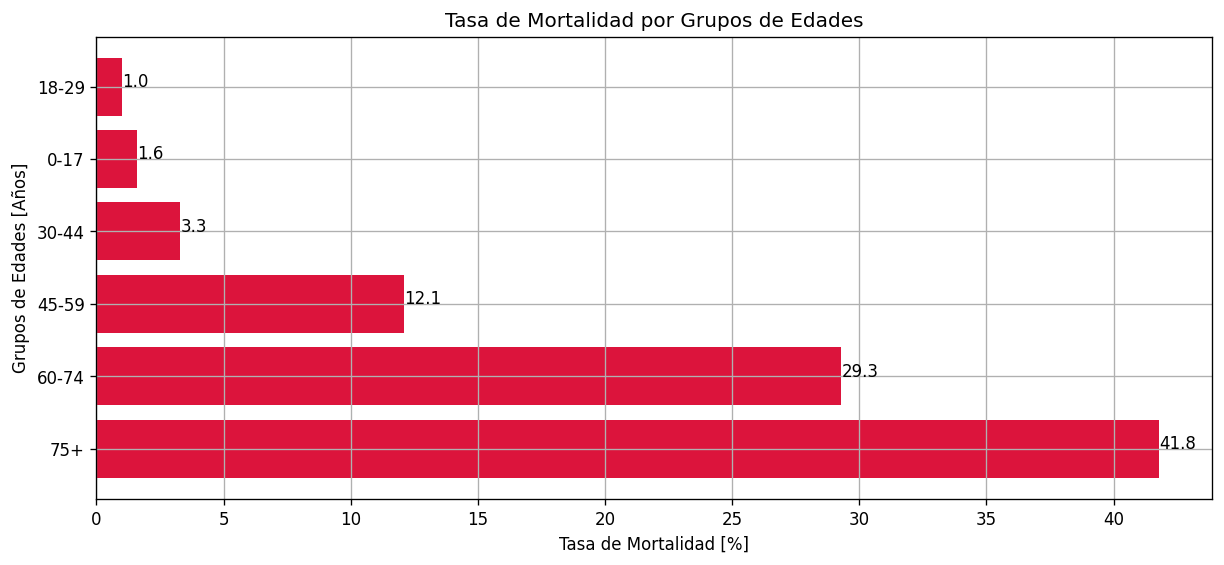

In [10]:
import duckdb
con = duckdb.connect()
con.register('covid',df_positivos)

#QUERY 1
mortalidad_edad = con.execute("""SELECT 
                    GRUPOS_EDAD,
                    COUNT(*) AS total_casos,
                    SUM(MUERTO) AS fallecidos,
                    ROUND(SUM(MUERTO) * 100 / COUNT(*),1) AS tasa_mortalidad
                FROM covid
                GROUP BY GRUPOS_EDAD
                ORDER BY tasa_mortalidad DESC
""").df()

plt.barh(mortalidad_edad['GRUPOS_EDAD'],mortalidad_edad['tasa_mortalidad'],color='crimson')
plt.title('Tasa de Mortalidad por Grupos de Edades')
plt.xlabel('Tasa de Mortalidad [%]')
plt.ylabel('Grupos de Edades [Años]')
plt.grid()

for grupos,tasa in zip(mortalidad_edad['GRUPOS_EDAD'],mortalidad_edad['tasa_mortalidad']):
    plt.text(tasa,grupos,tasa)
plt.savefig('mortalidad_por_edad.png', dpi=150, bbox_inches='tight')

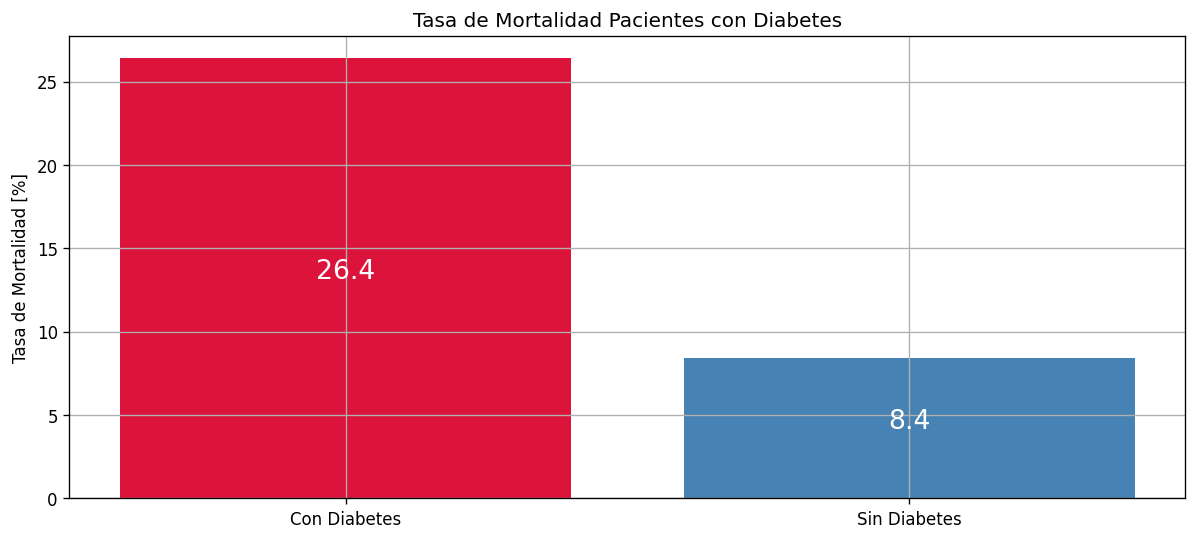

In [11]:
#QUERY 2 MORTALIDAD DIABETES

mortalidad_diabetes = con.execute("""
SELECT 
    DIABETES,
    COUNT(*) AS total_casos_diabetes,
    SUM(MUERTO) AS fallecidos_diabetes,
    ROUND(SUM(MUERTO) * 100 / COUNT(*),1) AS tasa_mortalidad_diabetes
FROM covid
GROUP BY DIABETES
ORDER BY tasa_mortalidad_diabetes DESC
""").df()


df_diabetes = mortalidad_diabetes.dropna(subset=['DIABETES'])
df_diabetes['LABEL_DIABETES'] = df_diabetes['DIABETES'].map({1.0:'Con Diabetes',0.0:'Sin Diabetes'})

plt.bar(df_diabetes['LABEL_DIABETES'],df_diabetes['tasa_mortalidad_diabetes'],color=['crimson','steelblue'])
plt.title('Tasa de Mortalidad Pacientes con Diabetes')
plt.ylabel('Tasa de Mortalidad [%]')
plt.grid()

for tipo,tasa in zip(df_diabetes['LABEL_DIABETES'],df_diabetes['tasa_mortalidad_diabetes']):
    plt.text(tipo,tasa/2,tasa,color='white',fontsize=16,horizontalalignment='center')

plt.savefig('mortalidad_por_edad.png', dpi=150, bbox_inches='tight')

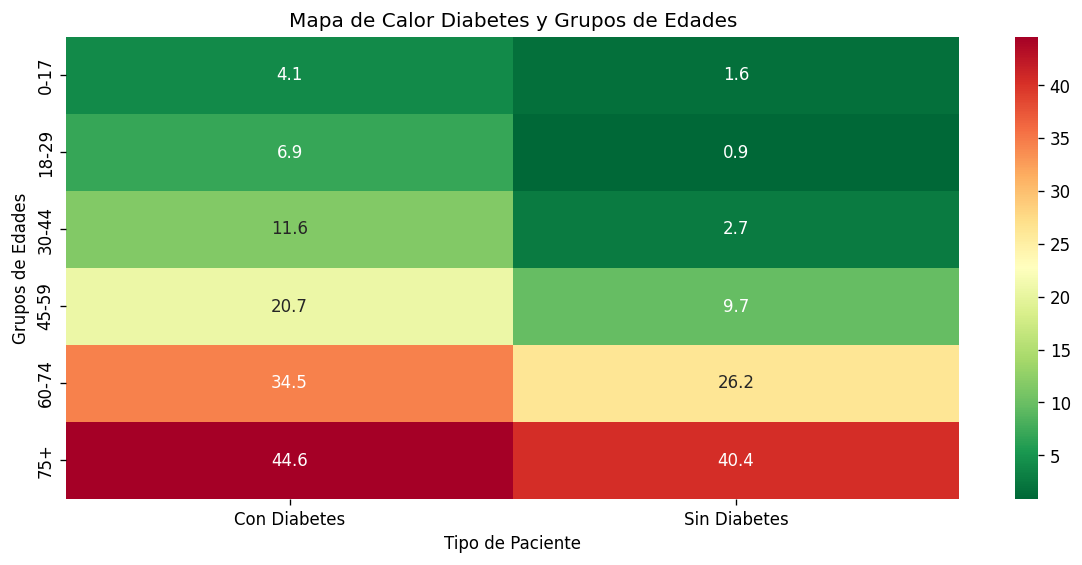

<Figure size 1440x600 with 0 Axes>

In [12]:
#HEATMAP DIABETES y EDAD

mortalidad_comb = con.execute("""
SELECT 
    GRUPOS_EDAD, DIABETES,
    COUNT(*) AS total_pacientes,
    SUM(MUERTO) AS fallecidos,
    ROUND(SUM(MUERTO) * 100 / COUNT(*),1) AS mortalidad_combinada
FROM covid
GROUP BY GRUPOS_EDAD , DIABETES
ORDER BY mortalidad_combinada DESC
""").df()

df_combinada = mortalidad_comb.dropna(subset=['DIABETES'])

df_combinada['label_diabetes'] = df_combinada['DIABETES'].map({1.0:'Con Diabetes',0.0:'Sin Diabetes'})

pivot = pd.pivot_table(df_combinada, values='mortalidad_combinada', index='GRUPOS_EDAD', columns='label_diabetes')

sns.heatmap(pivot,annot=True,fmt='.1f',cmap='RdYlGn_r')
plt.title('Mapa de Calor Diabetes y Grupos de Edades')
plt.ylabel('Grupos de Edades')
plt.xlabel('Tipo de Paciente')
plt.show()
plt.savefig('mortalidad_por_edad.png', dpi=150, bbox_inches='tight')

In [13]:
#QUERY 3 MORTALIDAD DE PACIENTES HOSPITALIZADOS
con.execute("""
SELECT 
    TIPO_PACIENTE,
    COUNT(*) AS total_pacientes,
    SUM(MUERTO) AS pac_fallecidos,
    ROUND(SUM(MUERTO) * 100 / COUNT(*),1) AS mortalidad_pac
FROM covid
GROUP BY TIPO_PACIENTE
ORDER BY mortalidad_pac DESC
""").df()

,TIPO_PACIENTE,total_pacientes,pac_fallecidos,mortalidad_pac
0,2,104231,37270.0,35.8
1,1,266481,4638.0,1.7


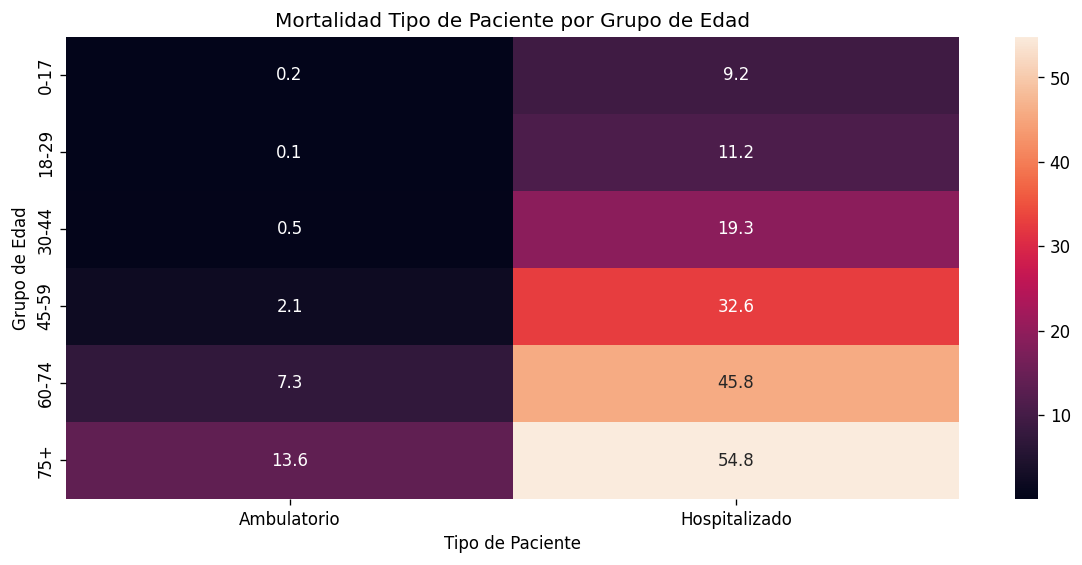

<Figure size 1440x600 with 0 Axes>

In [14]:
df_tipo_edad = con.execute("""
SELECT
    TIPO_PACIENTE,GRUPOS_EDAD,
    COUNT(*),
    SUM(MUERTO),
    ROUND(SUM(MUERTO) * 100 / COUNT(*),1) AS mortalidad_tipo_edad
FROM covid
GROUP BY TIPO_PACIENTE,GRUPOS_EDAD
ORDER BY mortalidad_tipo_edad DESC
""").df()

df_tipo_edad['label_tipo_pac'] = df_tipo_edad['TIPO_PACIENTE'].map({1:'Ambulatorio',2:'Hospitalizado'})

pivot_2 = pd.pivot_table(df_tipo_edad,values= 'mortalidad_tipo_edad',index='GRUPOS_EDAD',columns='label_tipo_pac')


sns.heatmap(pivot_2,annot=True,fmt='.1f')
plt.title('Mortalidad Tipo de Paciente por Grupo de Edad')
plt.xlabel('Tipo de Paciente')
plt.ylabel('Grupo de Edad')
plt.show()
plt.savefig('mortalidad_por_edad.png', dpi=150, bbox_inches='tight')

**Conclusiones**

Hallazgos Principales:

1. Los pacientes menores de 44 años tienen una tasa de mortalidad mínima en comparación a los pacientes de 45 años en adelante y existe un crecimiento sostenido en la tasa de mortalidad de pacientes de 75+ años en comparación con los menores de 17, la cual aumenta 26.1 veces.
2. La diabetes es una afección directamente relacionada con la tasa de muerte por covid, pues existe un contraste muy notorio en la mortalidad de pacientes sin diabetes a quienes si lo padecen, pasando del 8.4% (no diabetes) al 26.4% (con diabetes).
3. Si bien padecer o no diabetes no incrementa la tasa de mortalidad en gran medida para pacientes de edades avanzadas, se ve un aumento considerable en pacientes más jóvenes, siendo el grupo de 18-29 el más afectado pues quienes padecen diabetes tienen una tasa de mortalidad 7.6 veces más alta.
4. Si bien la hospitalización de pacientes de cualquier grupo de edad aumenta la tasa de mortalidad, el grupo de edad de 18-29 años es quien se ve mas afectado al momento de ser hospitalizado, pues la tasa de mortalidad aumenta aproximadamente 112 veces en comparación a ser un paciente ambulantorio.

Limitaciones del Análisis:

1. En el caso de comorbilidades se tuvieron que despreciar multiples datos pues no se tenía el registro de si padecian o no alguna afección, en caso de tener ese registro, el análisis podría ser más preciso.
2. Los datos disponibles solo están de enero del 2020 a junio del 2020, por lo que una mayor compilación de datos ayudaría a enriquecer el análisis y representaría información mas valiosa respecto los casos de covid en México durante la pandemia.

Próximos pasos:
1. Tomar en consideración otras comorbolidades, la obesidad y tabaquismo son padecimientos que podrían afectar directamente y en gran medida la tasa de mortalidad en pacientes que hayan padecido covid.
2. La entidad federativa podría estar directamente ligada con la tasa de mortalidad al tener diferente acceso a servicios de salud, densidad poblacional y condiciones ambientales, por lo que análizar esta variable sería de gran interés para obtener nuevos hallazgos.